# 01 - Imports

In [ ]:
import os
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# 02 - Importing DESRegression with multiple attempts to handle different environments

In [ ]:
try:
    import sys

    DESREG_V2_PATH = "/home/carlosh/me/mestrado/projeto-dissertacao/DESReg-v2"
    if DESREG_V2_PATH not in sys.path:
        sys.path.insert(0, DESREG_V2_PATH)

    for module_name in list(sys.modules):
        if module_name == "desReg_v2" or module_name.startswith("desReg_v2."):
            del sys.modules[module_name]

    from desReg_v2 import DESRegression
    print("Importado de: desReg_v2")
except ImportError:
    try:
        from desReg.des.DESRegression import DESRegression
        print("Importado de: desReg.des.DESRegression")
    except ImportError:
        try:
            from DESRegression import DESRegression
            print("Importado de: DESRegression")
        except ImportError as e:
            raise ImportError(
                "Não consegui importar DESRegression. "
                "Verifique se a pasta da DESREGv_2 está no sys.path ou se o pacote foi instalado no kernel correto."
            ) from e

# 03 - General Configs

In [ ]:
RANDOM_SEEDS = [0, 1, 2, 3, 4]

TEST_SIZE = 0.2

RARE_LOWER_Q = 0.10
RARE_UPPER_Q = 0.90

K_COMPETENCE = 5
DSEL_PERC = 0.5

OUTPUT_DIR = "outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figuras")
TABLE_DIR = os.path.join(OUTPUT_DIR, "tabelas")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

In [ ]:
DATASETS = {
    "lungcancer": {
        "path": "data/lungcancer_shedden.csv",
        "target": "target"
    },
    "mortgage": {
        "path": "data/mortgage.csv",
        "target": "target"
    },
    "fuel": {
        "path": "data/fuel_consumption_country.csv",
        "target": "fuel.consumption.country"
    }
}

In [ ]:
def load_dataset(path, target_col):
    df = pd.read_csv(path)

    df.columns = df.columns.str.strip()

    target_col = target_col.strip()
    if target_col not in df.columns:
        raise ValueError(f"Coluna alvo '{target_col}' não encontrada no dataset. Colunas disponíveis: {df.columns.tolist()}")
    
    df = df.dropna()

    X = df.drop(columns=[target_col])
    y = df[target_col].values

    X = X.select_dtypes(include=[np.number])

    return df, X, y

In [ ]:
def caracterizar_dataset(nome, X, y):
    p10 = np.quantile(y, RARE_LOWER_Q)
    p90 = np.quantile(y, RARE_UPPER_Q)

    rares = (y <= p10) | (y >= p90)

    return {
      "Dataset": nome,
      "Instances": len(y),
      "Features": X.shape[1],
      "Min_y": np.min(y),
      "Max_y": np.max(y),
      "Mean_y": np.mean(y),
      "Median_y": np.median(y),
      "P10_y": p10,
      "P90_y": p90,
      "Rares": rares.sum(),
      "Perc_Rares": rares.mean() * 100
    }

In [24]:
caracterizacoes = []

for nome, config in DATASETS.items():
    df, X, y = load_dataset(config["path"], config["target"])
    caracterizacoes.append(caracterizar_dataset(nome, X, y))

caracterizacao_df = pd.DataFrame(caracterizacoes)
caracterizacao_df

,Dataset,Instances,Features,Min_y,Max_y,Mean_y,Median_y,P10_y,P90_y,Rares,Perc_Rares
0,lungcancer,442,24,0.0025,17.00,4.383692,3.916667,0.849167,8.163333,90,20.361991
1,mortgage,1049,15,3.0200,17.15,7.543937,6.710000,4.222000,12.240000,210,20.019066
2,fuel,1764,37,2.7000,17.30,7.075283,6.900000,5.100000,9.270000,375,21.258503


In [25]:
caracterizacao_df.to_csv(
    os.path.join(TABLE_DIR, "caracterizacao_datasets.csv"),
    index=False
)

In [26]:
def plot_target_histogram(name, y):
    p10 = np.quantile(y, RARE_LOWER_Q)
    p90 = np.quantile(y, RARE_UPPER_Q)

    plt.figure(figsize=(8, 5))
    plt.hist(y, bins=30, color='skyblue', edgecolor='black')

    plt.axvline(p10, linestyle="dashed", label="P10")
    plt.axvline(p90, linestyle="dashed", label="P90")

    plt.xlabel("Target Value")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Target Variable - {name}")
    plt.legend()

    path = os.path.join(FIG_DIR, f"{name}_target_histogram.png")
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    return path

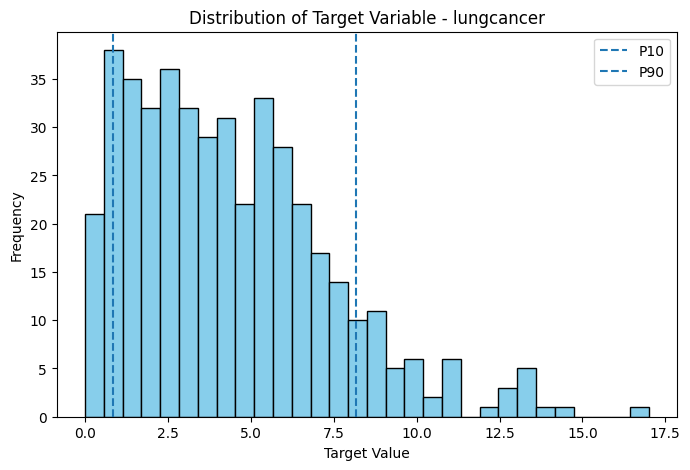

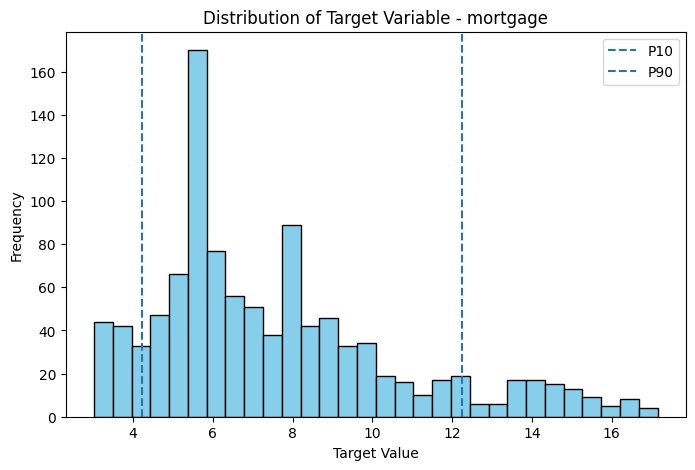

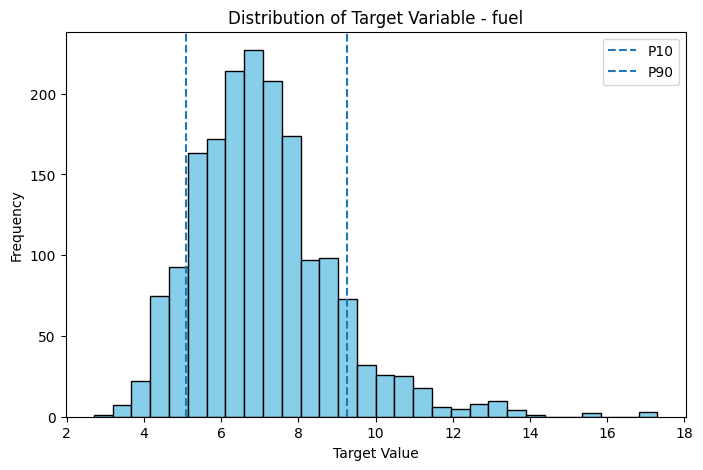

In [27]:
for nome, config in DATASETS.items():
    df, X, y = load_dataset(config["path"], config["target"])
    plot_target_histogram(nome, y)

In [28]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def calculate_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

def calculate_rare_metrics(y_true, y_pred, mask_rares):
    rares = int(mask_rares.sum())

    if rares == 0:
        return {
            "RARE_MAE": np.nan,
            "RARE_RMSE": np.nan,
            "RARES_TEST": 0,
            "PERC_RARES_TEST": 0
        }
    
    y_true_rare = y_true[mask_rares]
    y_pred_rare = y_pred[mask_rares]

    return {
        "MAE_RARE": mean_absolute_error(y_true_rare, y_pred_rare),
        "RMSE_RARE": rmse(y_true_rare, y_pred_rare),
        "RARES_TEST": rares,
        "PERC_RARES_TEST": mask_rares.mean() * 100
    }

In [29]:
def create_rare_mask(y_train, y_test):
    p10 = np.quantile(y_train, RARE_LOWER_Q)
    p90 = np.quantile(y_train, RARE_UPPER_Q)

    mask_rares_test = (y_test <= p10) | (y_test >= p90)
    
    return mask_rares_test, p10, p90

# Modelos Baseline

In [30]:
def create_bagging(seed):
    base_tree = DecisionTreeRegressor(random_state=seed)

    try:
        return BaggingRegressor(estimator=base_tree, n_estimators=50, random_state=seed, n_jobs=-1)
    except TypeError:
        return BaggingRegressor(base_estimator=base_tree, n_estimators=50, random_state=seed, n_jobs=-1)

def create_baseline_models(seed):
    return {
        "Decision Tree": DecisionTreeRegressor(random_state=seed),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=seed, n_jobs=-1),
        "Bagging": create_bagging(seed),
    }

In [31]:
def create_regressor_pool(seed):
    return [
        DecisionTreeRegressor(random_state=seed),
        KNeighborsRegressor(n_neighbors=5),
        RandomForestRegressor(n_estimators=50, random_state=seed, n_jobs=-1)
    ]

In [32]:
def create_desreg(ensemble_type, seed, k=K_COMPETENCE, dsel_perc=DSEL_PERC):
    pool = create_regressor_pool(seed)

    params = {
        "regressors_list": pool,
        "n_estimators_bag": 5,
        "DSEL_perc": dsel_perc,
        "k": k,
        "ensemble_type": ensemble_type,
        "n_jobs": -1
    }

    try:
        return DESRegression(**params)
    except TypeError:
        params.pop("n_jobs", None)
        return DESRegression(**params)


def criar_modelos_desreg(seed, k=K_COMPETENCE, dsel_perc=DSEL_PERC):
    return {
        "DESREG-SE": create_desreg("SE", seed, k, dsel_perc),
        "DESREG-DRS": create_desreg("DRS", seed, k, dsel_perc),
        "DESREG-DES": create_desreg("DES", seed, k, dsel_perc)
    }

In [33]:
def evaluate_model(
    nome_dataset,
    nome_modelo,
    modelo,
    X_train,
    X_test,
    y_train,
    y_test,
    mask_rares_test,
    seed,
    k=None,
    dsel_perc=None
):
    inicio = time.time()

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_pred = np.asarray(y_pred).reshape(-1)

    tempo = time.time() - inicio

    metricas = calculate_metrics(y_test, y_pred)
    metricas_raras = calculate_rare_metrics(y_test, y_pred, mask_rares_test)

    resultado = {
        "Dataset": nome_dataset,
        "Modelo": nome_modelo,
        "Seed": seed,
        "k": k,
        "DSEL_perc": dsel_perc,
        "Tempo_segundos": tempo,
        **metricas,
        **metricas_raras
    }

    return resultado, y_pred

In [34]:
results = []

example_preds = []

for dataset_name, config in DATASETS.items():
    print(f"\n=== Dataset: {dataset_name} ===")

    df, X, y = load_dataset(config["path"], config["target"])

    for seed in RANDOM_SEEDS:
        print(f"seed: {seed}")

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=seed)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        mask_rares_test, p10_train, p90_train = create_rare_mask(y_train, y_test)

        models = {}
        models.update(create_baseline_models(seed))
        models.update(criar_modelos_desreg(seed, k=K_COMPETENCE, dsel_perc=DSEL_PERC))

        for model_name, model in models.items():
            print(f"  Avaliando modelo: {model_name}")

            try:
                result, y_pred = evaluate_model(
                    dataset_name,
                    model_name,
                    model,
                    X_train_scaled,
                    X_test_scaled,
                    y_train,
                    y_test,
                    mask_rares_test,
                    seed,
                    k=K_COMPETENCE if "DESREG" in model_name else None,
                    dsel_perc=DSEL_PERC if "DESREG" in model_name else None
                )
                results.append(result)

                result["P10_train"] = p10_train
                result["P90_train"] = p90_train

                results.append(result)

                if seed == RANDOM_SEEDS[0]:
                    example_preds.append({
                        "Dataset": dataset_name,
                        "Modelo": model_name,
                        "y_test": y_test,
                        "y_pred": y_pred,
                        "mask_rares_test": mask_rares_test
                    })
            except Exception as e:
                print(f"    Erro ao avaliar {model_name} no dataset {dataset_name} com seed {seed}: {e}")
                continue
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(TABLE_DIR, "resultados_experimentos.csv"), index=False)


=== Dataset: lungcancer ===
seed: 0
  Avaliando modelo: Decision Tree
  Avaliando modelo: Random Forest
  Avaliando modelo: Bagging
  Avaliando modelo: DESREG-SE
  Avaliando modelo: DESREG-DRS
    Erro ao avaliar DESREG-DRS no dataset lungcancer com seed 0: only integer scalar arrays can be converted to a scalar index
  Avaliando modelo: DESREG-DES


KeyboardInterrupt: 